<a href="https://colab.research.google.com/github/florenciazoni/Ciencia-de-Datos/blob/main/grupo4_indicadores_escolares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GRUPO 4

INTEGRANTES: FLORENCIA ZONI, VIRGINIA CONTRERAS, ALEJANDRA YAMIN

Este proyecto analiza el dataset de **Indicadores Educativos de Datos Argentina** con el fin de estudiar la dinámica escolar en el país.

## Objetivo
Analizar la evolución y distribución territorial de las tasas críticas del sistema educativo (como el abandono, la repitencia y la promoción) para identificar las jurisdicciones y niveles educativos que presentan mayores desafíos y orientar futuras propuestas de intervención o modelos predictivos.

Importación de librerias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



Carga de datos

In [4]:
# Carga de datos
df = pd.read_csv('2025 Trayectoria - agregada(in).csv',sep=';', encoding='latin1')

# Visualizar las primeras filas
print("Primeras filas del dataset:")
display(df.head())

Primeras filas del dataset:


,provincia,departamento,sector,ambito,inicial_1,inicial_2,inicial_3,inicial_4,inicial_5,inicial_6,...,m_otros_9,m_otros_10,m_otros_11,m_otros_12,m_otros_1314,m_otros_20,primaria_egresados,primaria_m_egresados,secundaria_egresados,secundaria_m_egresados
0,Buenos Aires,25 DE MAYO,Estatal,Rural,84,104,93,96,95,98,...,0,0,0,0,,,96,39,83,33
1,Buenos Aires,25 DE MAYO,Estatal,Urbano,314,317,329,360,315,319,...,0,0,0,0,0,,323,159,238,135
2,Buenos Aires,25 DE MAYO,Privado,Urbano,138,136,144,142,130,149,...,0,0,0,0,,,145,62,99,60
3,Buenos Aires,9 DE JULIO,Estatal,Rural,93,121,91,132,130,117,...,0,0,0,0,0,,117,57,96,48
4,Buenos Aires,9 DE JULIO,Estatal,Urbano,485,498,538,525,517,512,...,0,0,0,0,0,,509,249,408,208


Inspección inicial (Tipos de datos y nulos)

In [5]:
print("--- INFORMACIÓN GENERAL ---")
df.info()

print("\n--- VALORES NULOS POR COLUMNA ---")
print(df.isnull().sum())

--- INFORMACIÓN GENERAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1210 entries, 0 to 1209
Columns: 316 entries, provincia to secundaria_m_egresados
dtypes: object(316)
memory usage: 2.9+ MB

--- VALORES NULOS POR COLUMNA ---
provincia                 0
departamento              0
sector                    0
ambito                    0
inicial_1                 0
                         ..
m_otros_20                0
primaria_egresados        0
primaria_m_egresados      0
secundaria_egresados      0
secundaria_m_egresados    0
Length: 316, dtype: int64


Limpieza y Transformación de Datos

In [6]:
# Ejemplo de limpieza: eliminar filas completamente vacías o duplicadas
df = df.dropna(how='all')
df = df.drop_duplicates()

# Limpieza de columnas de texto (por ejemplo, Jurisdicción / Provincia)
if 'jurisdiccion' in df.columns:
    df['jurisdiccion'] = df['jurisdiccion'].str.strip().str.title()

# Asegurar que las columnas numéricas (tasas, alumnos, etc.) tengan el formato correcto
# (Modificá 'valor' o las columnas numéricas reales de tu dataset)
# df['valor'] = pd.to_numeric(df['valor'], errors='coerce')

print("Dimensiones del DataFrame tras la limpieza:", df.shape)

Dimensiones del DataFrame tras la limpieza: (1210, 316)


Estadísticas descriptivas

In [7]:
print("--- ESTADÍSTICAS DESCRIPTIVAS ---")
display(df.describe())

--- ESTADÍSTICAS DESCRIPTIVAS ---


,provincia,departamento,sector,ambito,inicial_1,inicial_2,inicial_3,inicial_4,inicial_5,inicial_6,...,m_otros_9,m_otros_10,m_otros_11,m_otros_12,m_otros_1314,m_otros_20,primaria_egresados,primaria_m_egresados,secundaria_egresados,secundaria_m_egresados
count,1210,1210,1210,1210,1210,1210,1210,1210,1210,1210,...,1210,1210,1210,1210,1210,1210,1210,1210,1210,1210
unique,24,437,2,2,642,654,664,668,662,665,...,24,26,22,43,13,2,655,493,519,408
top,Buenos Aires,Enmascarado,Estatal,Urbano,49,,,,,,...,0,0,0,0,0,,59,64,,
freq,325,67,903,712,12,11,13,11,11,11,...,1074,1069,1059,954,678,1207,10,13,27,27


Visualización de Datos con Pandas / Seaborn

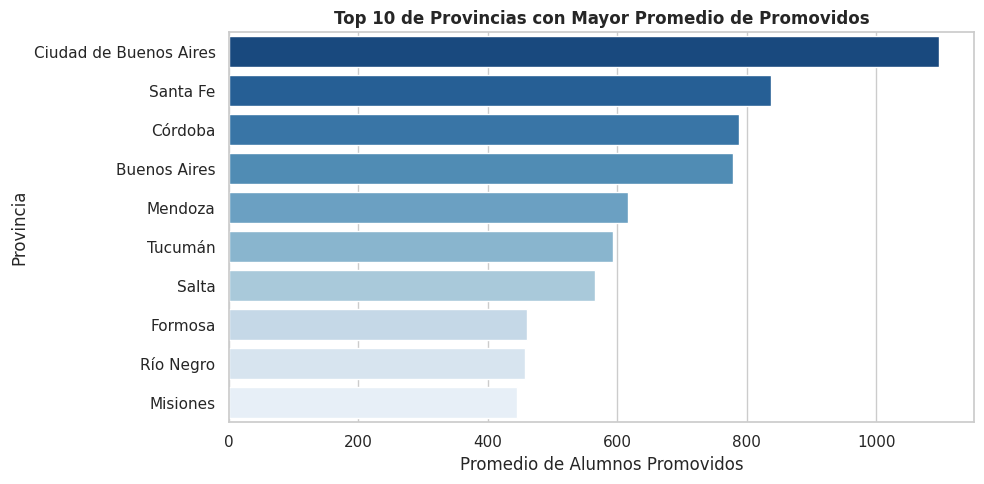

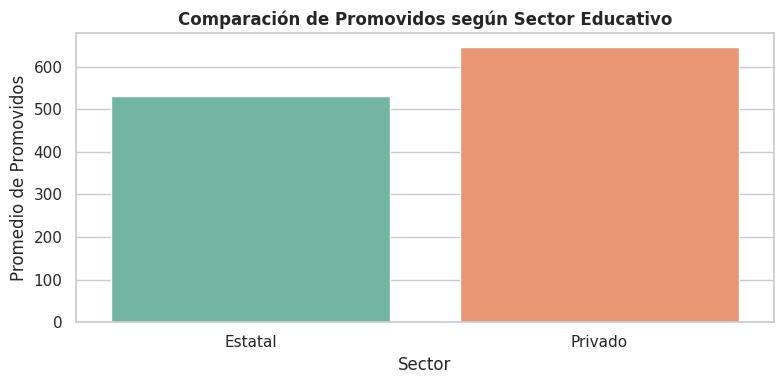

In [10]:

# Configuración visual
sns.set_theme(style="whitegrid")

# Aseguramos que la columna sea numérica
df['promovidos_1_num'] = pd.to_numeric(df['promovidos_1'], errors='coerce')

# --- GRÁFICO 1: Top 10 de Provincias con mayor promedio ---
if 'provincia' in df.columns:
    df_grouped = df.groupby('provincia')['promovidos_1_num'].mean().reset_index()
    df_sorted = df_grouped.sort_values(by='promovidos_1_num', ascending=False).head(10)

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=df_sorted,
        x='promovidos_1_num',
        y='provincia',
        hue='provincia',
        palette='Blues_r',
        legend=False
    )
    plt.title('Top 10 de Provincias con Mayor Promedio de Promovidos', fontsize=12, fontweight='bold')
    plt.xlabel('Promedio de Alumnos Promovidos')
    plt.ylabel('Provincia')
    plt.tight_layout()
    plt.show()

# --- GRÁFICO 2: Comparación por Sector (Estatal vs Privado) ---
if 'sector' in df.columns:
    df_sector = df.groupby('sector')['promovidos_1_num'].mean().reset_index()

    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=df_sector,
        x='sector',
        y='promovidos_1_num',
        hue='sector',
        palette='Set2',
        legend=False
    )
    plt.title('Comparación de Promovidos según Sector Educativo', fontsize=12, fontweight='bold')
    plt.xlabel('Sector')
    plt.ylabel('Promedio de Promovidos')
    plt.tight_layout()
    plt.show()